# FIFA World Cup 2026 Predictor - LinkedIn Presentation

---

## Project Overview

Welcome to my FIFA 2026 Match Predictor! In this notebook we'll walk through the project and make professional visualizations perfect for sharing on LinkedIn!

---
## 1. Setup Paths & Load Libraries

First let's add the project root directory to Python's path, then load all resources!

In [1]:
# Add project root to path so we can import predict_match
import sys
import importlib
from pathlib import Path

# Get project root directory (parent of notebooks/)
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

if 'predict_match' in sys.modules:
    importlib.reload(sys.modules['predict_match'])

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import poisson
import pickle
import os
from predict_match import predict_match

# Display plots inline in the notebook
%matplotlib inline

# Set professional style for visualizations
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=0.85)
FIGSIZE = (8, 6)
DPI = 100

print("All libraries imported!")

All libraries imported!


---
## 2. Load Trained Models & Resources

In [2]:
# Use project root for file paths
models_dir = project_root / "models"

with open(models_dir / "xgboost_v1.pkl", "rb") as f:
    win_model = pickle.load(f)
with open(models_dir / "xg_home_model.pkl", "rb") as f:
    xg_home = pickle.load(f)
with open(models_dir / "xg_away_model.pkl", "rb") as f:
    xg_away = pickle.load(f)

print("Models loaded!")

Models loaded!


---
## 3. Pick a Match for Predictions!

Let's look at matches on 2026-06-11!

In [3]:
data_dir = project_root / "data"
results = pd.read_csv(data_dir / "results.csv")
date = '2026-07-04'
matches = results[results['date'] == date]
matches[['home_team', 'away_team', 'tournament']]

,home_team,away_team,tournament
49394,Canada,Morocco,FIFA World Cup
49395,Paraguay,France,FIFA World Cup


---
## 4. Create LinkedIn Visualizations!

Let's define our functions to make beautiful charts!

In [4]:
def generate_outcome_chart(home_team, away_team, probs, date_str="2026-07-04", prediction=None):
    has_advance = prediction is not None and 'advance_probs' in prediction
    
    if has_advance:
        # Create a 2-panel subplot side-by-side
        fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=FIGSIZE, dpi=DPI, gridspec_kw={'width_ratios': [5, 4]})
        
        # Panel 1: 90-Minute Outcome Probabilities
        colors1 = ["#1E88E5", "#FF6B35", "#004E89"]
        labels1 = [f"{home_team} Win", "Draw", f"{away_team} Win"]
        percentages1 = [p * 100 for p in probs]
        
        bars1 = ax1.barh(labels1, percentages1, color=colors1, height=0.5, edgecolor="white", linewidth=2)
        for bar in bars1:
            width = bar.get_width()
            ax1.text(width + 1, bar.get_y() + bar.get_height() / 2,
                    f'{width:.1f}%', va='center', ha='left',
                    fontsize=14, fontweight='bold')
                    
        ax1.set_xlim(0, 100)
        ax1.set_xlabel('Probability (%)', fontsize=14, fontweight='bold')
        ax1.tick_params(axis='both', labelsize=12)
        ax1.grid(axis='x', linestyle='--', alpha=0.7)
        ax1.set_title("90-Minute Match Outcomes", fontsize=15, fontweight='bold', pad=10)
        
        # Panel 2: Penalty Shootout Win Probabilities
        colors2 = ["#1E88E5", "#004E89"]
        labels2 = [f"{home_team}\nSO Win", f"{away_team}\nSO Win"]
        p_home_so, p_away_so = prediction['shootout_probs']
        percentages2 = [p_home_so * 100, p_away_so * 100]
        
        bars2 = ax2.barh(labels2, percentages2, color=colors2, height=0.4, edgecolor="white", linewidth=2)
        for bar in bars2:
            width = bar.get_width()
            ax2.text(width + 1, bar.get_y() + bar.get_height() / 2,
                    f'{width:.1f}%', va='center', ha='left',
                    fontsize=14, fontweight='bold')
                    
        ax2.set_xlim(0, 100)
        ax2.set_xlabel('Probability (%)', fontsize=14, fontweight='bold')
        ax2.tick_params(axis='both', labelsize=12)
        ax2.grid(axis='x', linestyle='--', alpha=0.7)
        ax2.set_title("Penalty Shootout Likelihood", fontsize=15, fontweight='bold', pad=10)
        
        # Set main title with overall advancement probabilities
        p_home_adv, p_away_adv = prediction['advance_probs']
        fig.suptitle(f"FIFA World Cup Knockout: {home_team} vs {away_team} (Draw Expected)\n"
                     f"Overall to Advance: {home_team} {p_home_adv*100:.1f}% | {p_away_adv*100:.1f}% {away_team}",
                     fontsize=18, fontweight='bold', y=0.98)
    else:
        # Standard 1-panel Outcome Chart
        fig, ax = plt.subplots(figsize=FIGSIZE, dpi=DPI)
        colors = ["#1E88E5", "#FF6B35", "#004E89"]
        labels = [f"{home_team} Win", "Draw", f"{away_team} Win"]
        percentages = [p * 100 for p in probs]
        
        bars = ax.barh(labels, percentages, color=colors, height=0.6, edgecolor="white", linewidth=2)
        
        for bar in bars:
            width = bar.get_width()
            ax.text(width + 1, bar.get_y() + bar.get_height() / 2,
                    f'{width:.1f}%', va='center', ha='left',
                    fontsize=16, fontweight='bold')
        
        ax.set_xlim(0, 100)
        ax.set_xlabel('Probability (%)', fontsize=16, fontweight='bold')
        ax.tick_params(axis='both', labelsize=14)
        ax.grid(axis='x', linestyle='--', alpha=0.7)
        
        fig.suptitle(f"FIFA World Cup Prediction: {home_team} vs {away_team}",
                     fontsize=20, fontweight='bold', y=0.98)
        ax.set_title(f"Date: {date_str} | Model: XGBoost + Poisson xG",
                     fontsize=14, pad=15)
        
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    
    # Save to project root's visualizations_linkedin
    viz_dir = project_root / "visualizations_linkedin"
    viz_dir.mkdir(exist_ok=True)
    filename = viz_dir / f"{home_team.replace(' ', '_')}_vs_{away_team.replace(' ', '_')}_prob.png"
    plt.savefig(filename, dpi=DPI, bbox_inches='tight')
    print(f"Saved outcome chart: {filename}")
    plt.show()
    plt.close(fig)

In [5]:
def generate_score_heatmap(home_team, away_team, home_xg, away_xg, date_str="2026-07-04", prediction=None):
    fig, (ax_heatmap, ax_summary) = plt.subplots(ncols=2, figsize=FIGSIZE, dpi=DPI, gridspec_kw={'width_ratios': [3, 1]})
    
    max_goals=5
    score_matrix = np.zeros((max_goals+1, max_goals+1))
    
    for i in range(max_goals+1):
        for j in range(max_goals+1):
            score_matrix[i,j] = poisson.pmf(i, home_xg) * poisson.pmf(j, away_xg) * 100
    
    home_goals, away_goals = np.unravel_index(np.argmax(score_matrix), score_matrix.shape)
    
    sns.heatmap(score_matrix, annot=True, fmt=".1f", cmap="Blues", cbar=True,
                ax=ax_heatmap, linewidths=0.8, edgecolor="white",
                cbar_kws={"shrink": 0.85, "label": "Probability (%)"})
    
    ax_heatmap.set_xticklabels([str(x) for x in range(max_goals+1)], fontsize=12)
    ax_heatmap.set_yticklabels([str(y) for y in range(max_goals+1)], fontsize=12, rotation=0)
    ax_heatmap.set_xlabel(f"{away_team} Goals", fontsize=14, fontweight='bold', labelpad=10)
    ax_heatmap.set_ylabel(f"{home_team} Goals", fontsize=14, fontweight='bold', labelpad=10)
    ax_heatmap.set_title("Predicted Score Distribution", fontsize=16, fontweight='bold', pad=15)
    ax_heatmap.add_patch(mpatches.Rectangle((away_goals, home_goals), 1, 1, fill=False, edgecolor="#E63946", linewidth=4))
    
    ax_summary.axis("off")
    summary_text = [
        f"{home_team} xG: {home_xg:.2f}",
        f"{away_team} xG: {away_xg:.2f}",
        "",
        "MOST LIKELY SCORE:",
        f" {home_team} {home_goals} - {away_goals} {away_team}",
        "",
        f"Confidence: {score_matrix[home_goals, away_goals]:.1f}%"
    ]
    
    if prediction is not None and 'shootout_probs' in prediction:
        p_home_so, p_away_so = prediction['shootout_probs']
        fav_team = home_team if p_home_so > p_away_so else away_team
        fav_prob = max(p_home_so, p_away_so) * 100
        summary_text.extend([
            "",
            "SHOOTOUT VERDICT:",
            f" {fav_team} favored",
            f" to win SO ({fav_prob:.1f}%)"
        ])
        
    for i, line in enumerate(summary_text):
        weight = "bold" if "MOST LIKELY" in line or "SHOOTOUT VERDICT" in line else "normal"
        size = 16 if "MOST LIKELY" in line or "SHOOTOUT VERDICT" in line else 14
        ax_summary.text(0.1, 0.95-(i*0.075), line, transform=ax_summary.transAxes, fontsize=size, fontweight=weight, va='top')
    
    fig.suptitle(f"FIFA World Cup 2026: {home_team} vs {away_team}", fontsize=20, fontweight='bold', y=0.98)
    plt.tight_layout(rect=[0,0,1,0.95])
    
    # Save to project root's visualizations_linkedin
    viz_dir = project_root / "visualizations_linkedin"
    viz_dir.mkdir(exist_ok=True)
    filename = viz_dir / f"{home_team.replace(' ', '_')}_vs_{away_team.replace(' ', '_')}_score.png"
    plt.savefig(filename, dpi=DPI, bbox_inches='tight')
    print(f"Score chart saved: {filename}")
    plt.show()
    plt.close(fig)

---
## 5. Predict & Visualize a Match!

## Let's pick Canada vs Morocco


Match Prediction: Canada vs Morocco
Location: Neutral
--------------------------------------------------
Probabilities: Canada 12.3% | Draw 28.1% | Morocco 59.6%
Expected Goals (xG): Canada 0.96 - 1.62 Morocco
Most Likely Score: 0 - 1 (12.2% confidence)
--------------------------------------------------
Saved outcome chart: c:\Users\nitindave\Desktop\FIFA 2026\visualizations_linkedin\Canada_vs_Morocco_prob.png


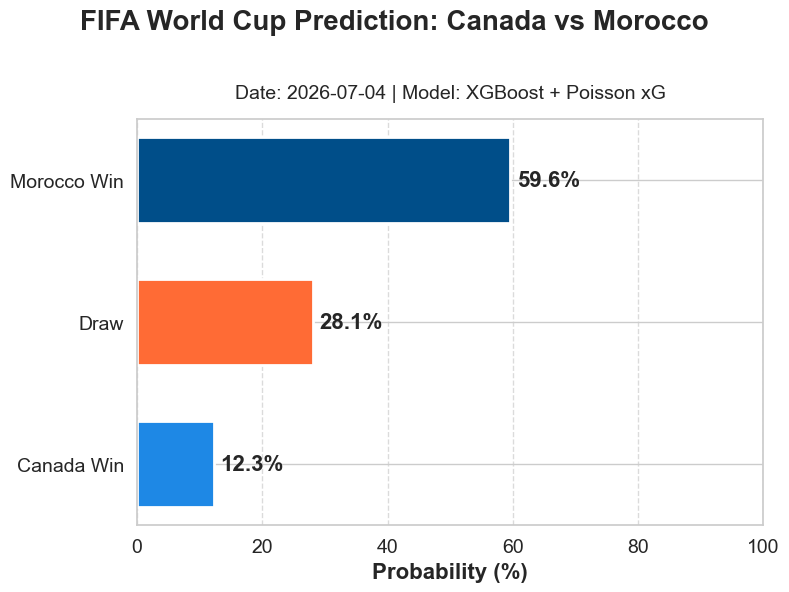

Score chart saved: c:\Users\nitindave\Desktop\FIFA 2026\visualizations_linkedin\Canada_vs_Morocco_score.png


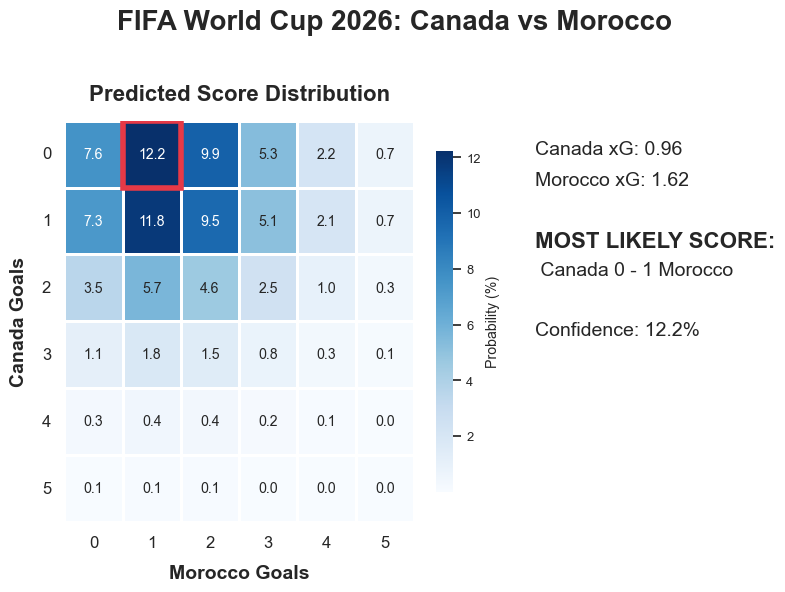

In [6]:
pred = predict_match("Canada", "Morocco")
if pred:
    probs, (home_xg, away_xg) = pred['probs'], pred['xg']
    generate_outcome_chart("Canada", "Morocco", probs)
    generate_score_heatmap("Canada", "Morocco", home_xg, away_xg)

---
## 6. Second Match: Paraguay vs France


Match Prediction: Paraguay vs France
Location: Neutral
--------------------------------------------------
Probabilities: Paraguay 3.3% | Draw 7.1% | France 89.6%
Expected Goals (xG): Paraguay 0.81 - 2.50 France
Most Likely Score: 0 - 2 (11.4% confidence)
--------------------------------------------------
Saved outcome chart: c:\Users\nitindave\Desktop\FIFA 2026\visualizations_linkedin\Paraguay_vs_France_prob.png


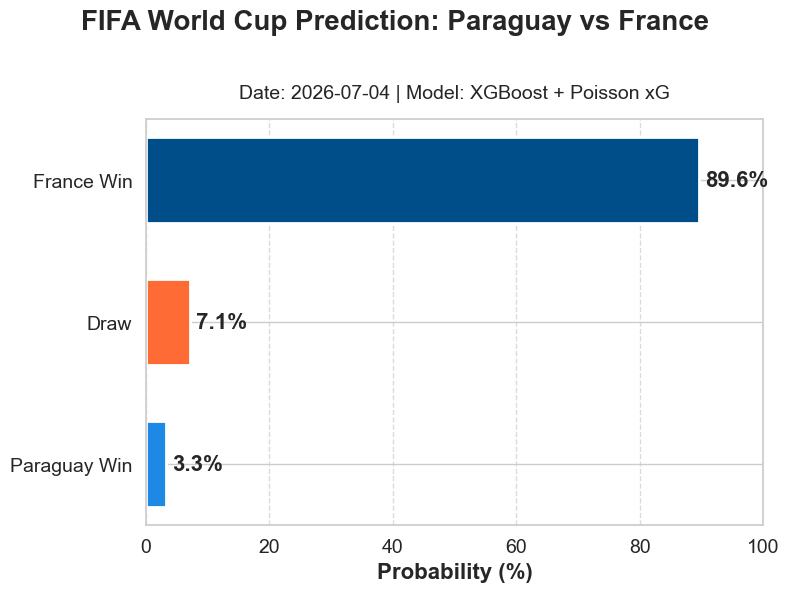

Score chart saved: c:\Users\nitindave\Desktop\FIFA 2026\visualizations_linkedin\Paraguay_vs_France_score.png


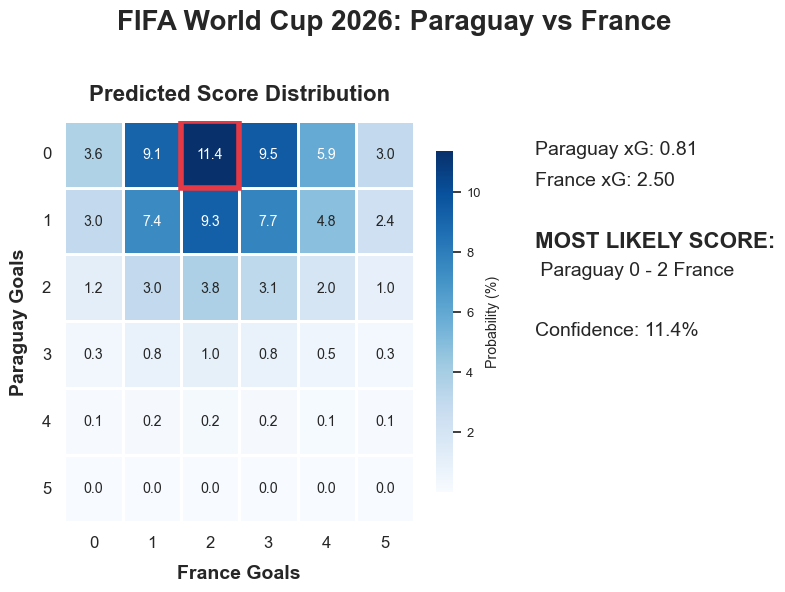

In [7]:
pred = predict_match("Paraguay", "France")
if pred:
    probs, (home_xg, away_xg) = pred['probs'], pred['xg']
    generate_outcome_chart("Paraguay", "France", probs)
    generate_score_heatmap("Paraguay", "France", home_xg, away_xg)

---
## Check Generated Files!

Check your project root directory's `visualizations_linkedin` folder to see your beautiful LinkedIn-ready charts!